<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/simulation/v_kernel_field_visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import math
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
NUM_NODES = 30
CONNECTION_PROB = 0.1
NOISE_LEVEL = 0.6
PRUNE_THRESHOLD = 0.2
ITERATIONS = 25

In [3]:
G = nx.DiGraph()

for i in range(NUM_NODES):
    G.add_node(i, value=random.uniform(-1, 1))

for i in range(NUM_NODES):
    for j in range(NUM_NODES):
        if i != j and random.random() < CONNECTION_PROB:
            G.add_edge(i, j, weight=random.uniform(0.1, 1.0))

In [4]:
def add_noise(G):
    for n in G.nodes:
        G.nodes[n]["value"] += random.uniform(-NOISE_LEVEL, NOISE_LEVEL)

def forward_pass(G):
    new_values = {}
    for n in G.nodes:
        total = 0
        for pred in G.predecessors(n):
            w = G[pred][n]["weight"]
            total += G.nodes[pred]["value"] * w
        new_values[n] = total
    return new_values

def normalize(G, new_values):
    total = sum(abs(v) for v in new_values.values()) + 1e-6
    for n in G.nodes:
        G.nodes[n]["value"] = new_values[n] / total

def reinforce(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= random.uniform(0.9, 1.1)

def decay(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= 0.95

def prune(G):
    to_remove = []
    for u, v in G.edges:
        if abs(G[u][v]["weight"]) < PRUNE_THRESHOLD:
            to_remove.append((u, v))
    for edge in to_remove:
        G.remove_edge(*edge)
    return len(to_remove)

def coherence(G):
    vals = [G.nodes[n]["value"] for n in G.nodes]
    mean = sum(vals) / len(vals)
    var = sum((v - mean) ** 2 for v in vals) / len(vals)
    return 1 / (1 + var)

In [5]:
def draw_graph(G, step, coh):
    plt.figure(figsize=(6,6))

    pos = nx.spring_layout(G, seed=42)

    values = [G.nodes[n]["value"] for n in G.nodes]

    # кольори (синій → стабільно, червоний → хаос)
    colors = []
    for v in values:
        if v > 0:
            colors.append((1-v, 0.2, v))
        else:
            colors.append((abs(v), 0.2, 1-abs(v)))

    nx.draw(
        G,
        pos,
        node_color=colors,
        with_labels=False,
        node_size=100,
        edge_color="gray",
        alpha=0.8
    )

    plt.title(f"Step {step} | Coherence: {coh:.3f}")
    plt.show()

=== V-KERNEL FIELD SIMULATION ===
[STEP 0] coherence=0.9981 edges=70 pruned=13


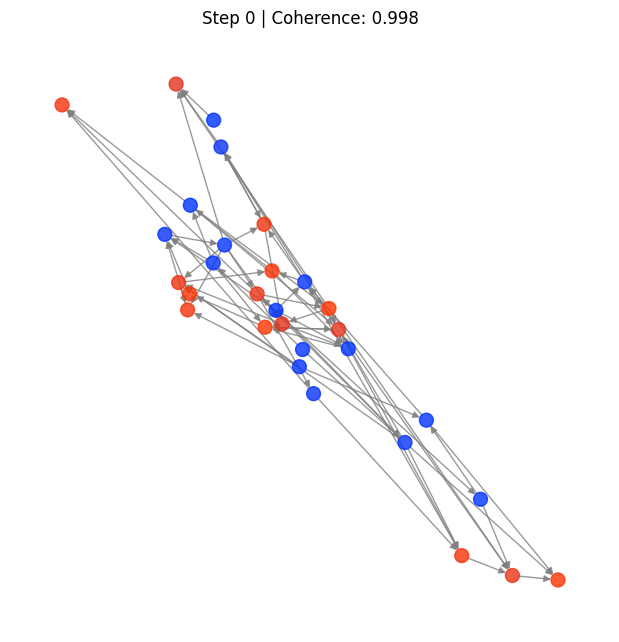

[STEP 1] coherence=0.9981 edges=66 pruned=4


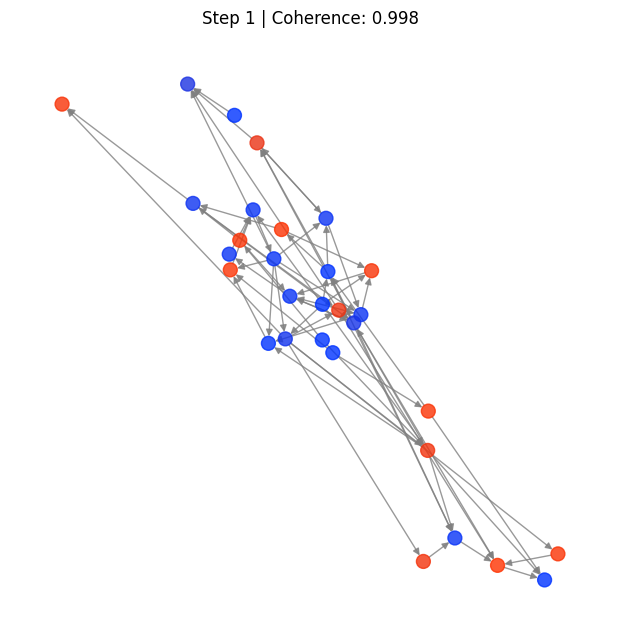

[STEP 2] coherence=0.9980 edges=65 pruned=1


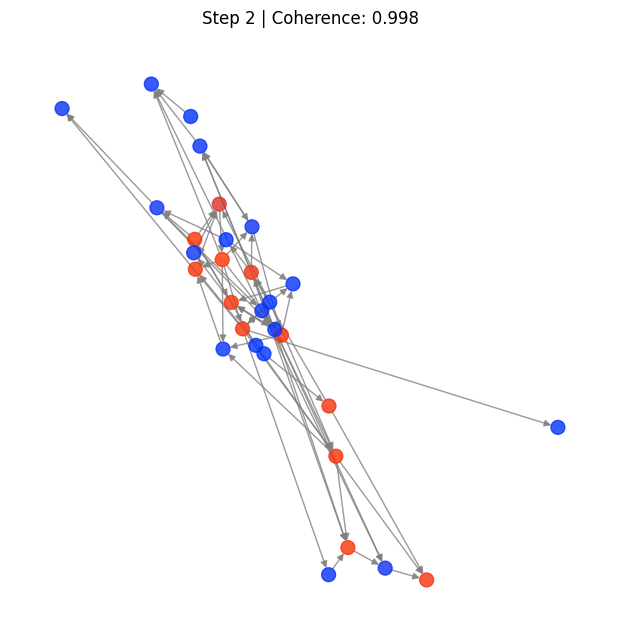

[STEP 3] coherence=0.9977 edges=64 pruned=1


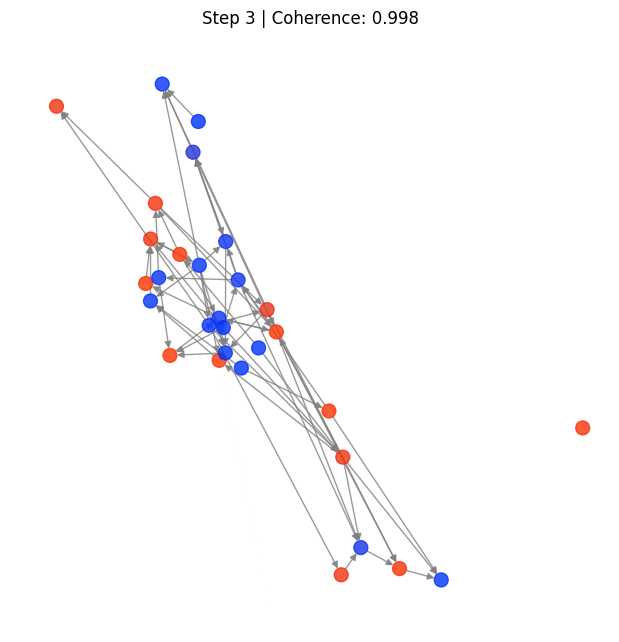

[STEP 4] coherence=0.9987 edges=62 pruned=2


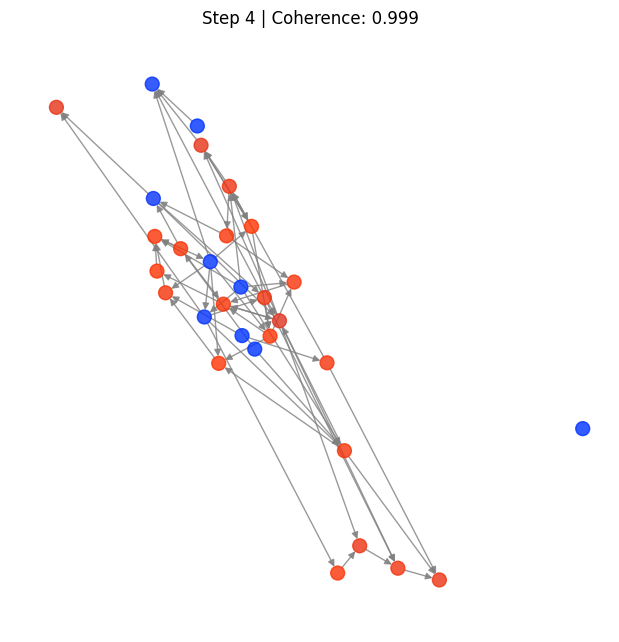

[STEP 5] coherence=0.9978 edges=60 pruned=2


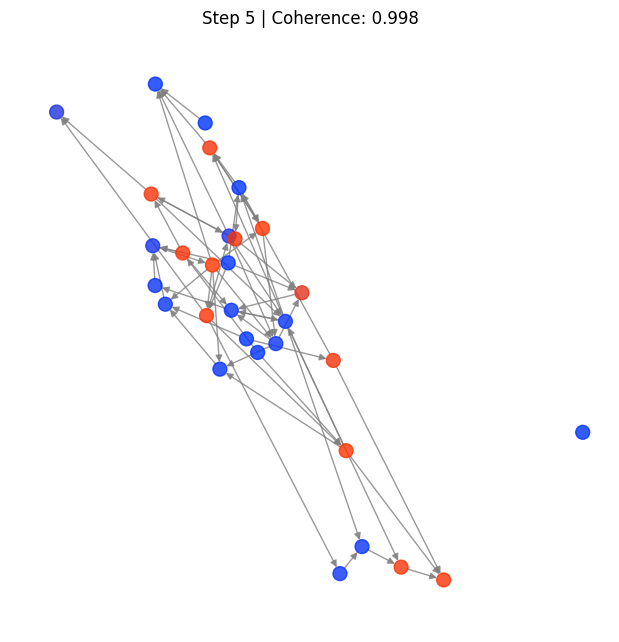

[STEP 6] coherence=0.9977 edges=57 pruned=3


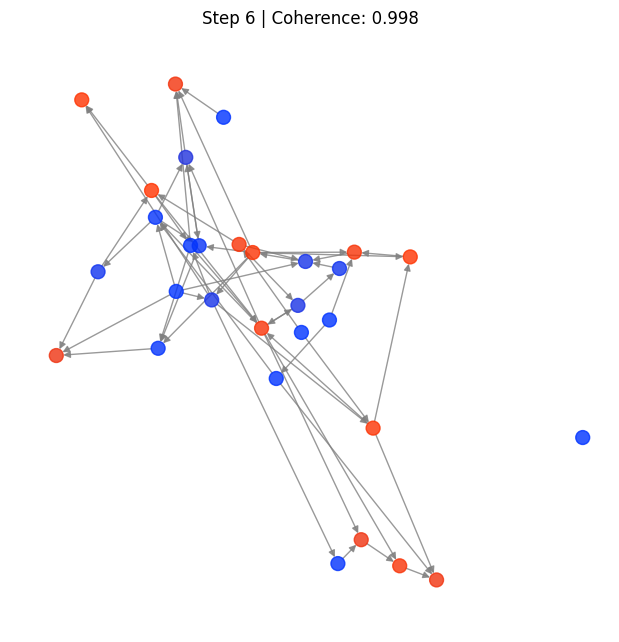

[STEP 7] coherence=0.9980 edges=56 pruned=1


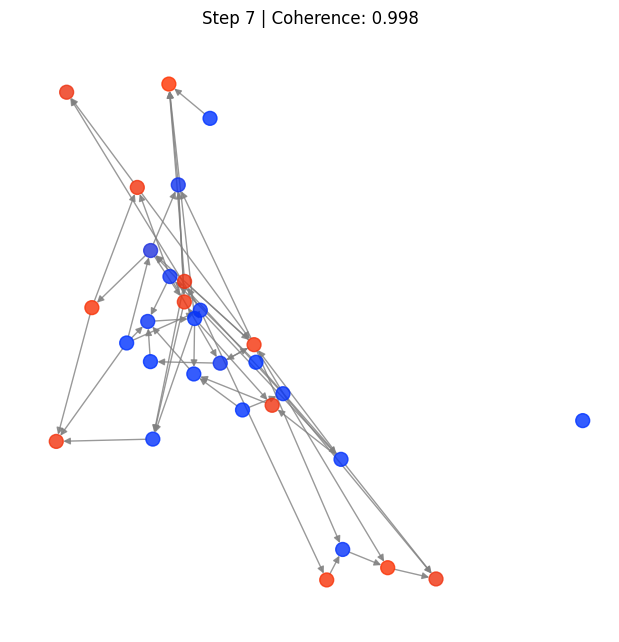

[STEP 8] coherence=0.9983 edges=54 pruned=2


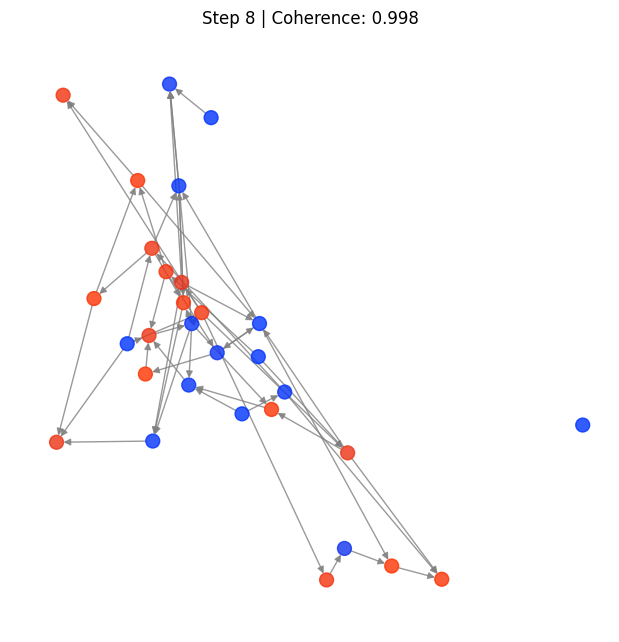

[STEP 9] coherence=0.9982 edges=50 pruned=4


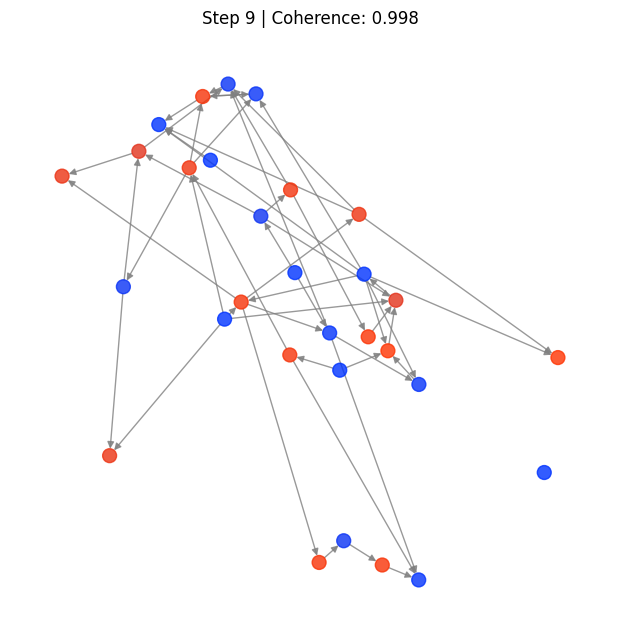

[STEP 10] coherence=0.9978 edges=50 pruned=0


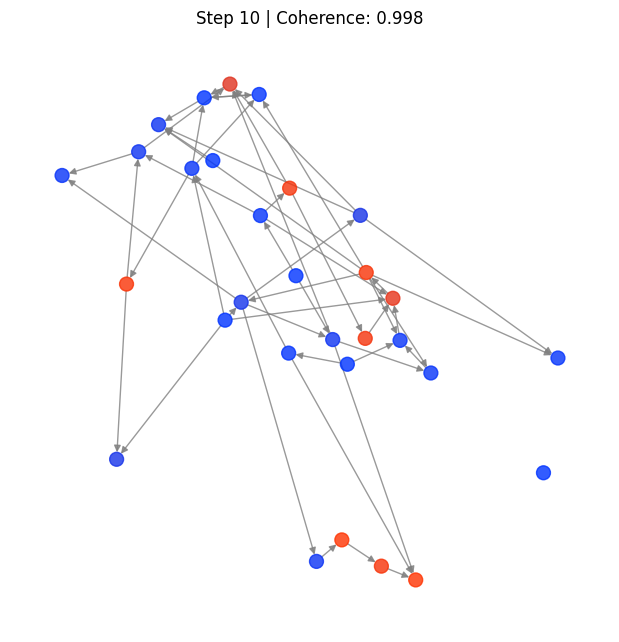

[STEP 11] coherence=0.9978 edges=47 pruned=3


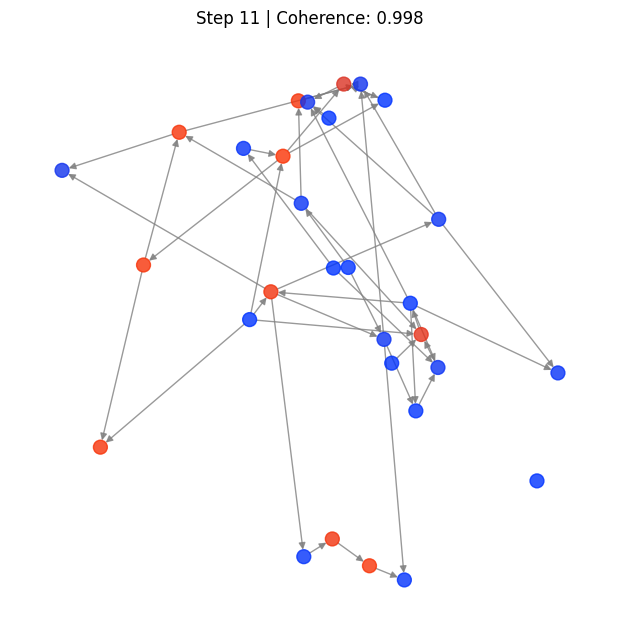

[STEP 12] coherence=0.9982 edges=45 pruned=2


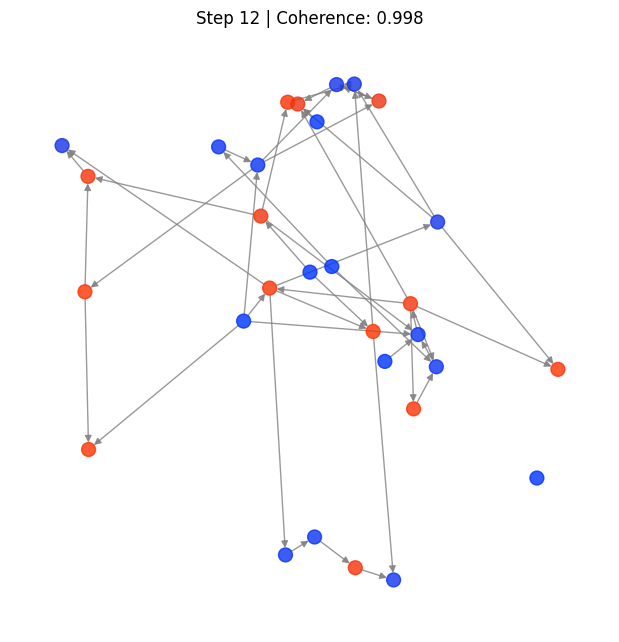

[STEP 13] coherence=0.9980 edges=43 pruned=2


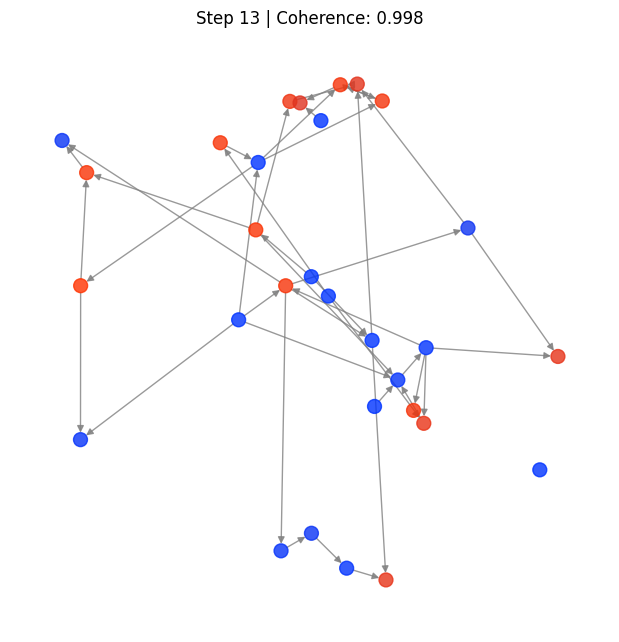

[STEP 14] coherence=0.9982 edges=41 pruned=2


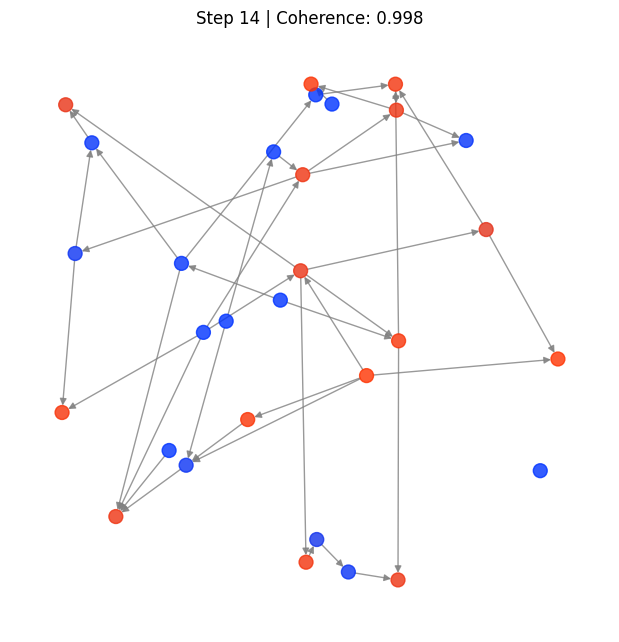

[STEP 15] coherence=0.9987 edges=40 pruned=1


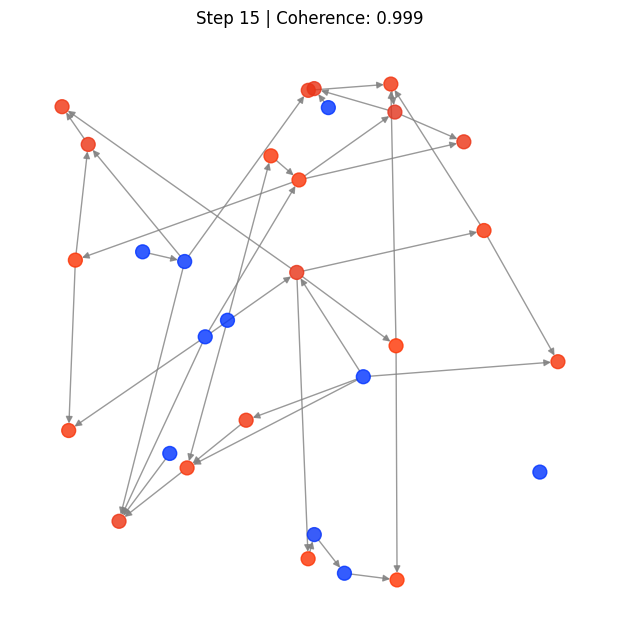

[STEP 16] coherence=0.9978 edges=37 pruned=3


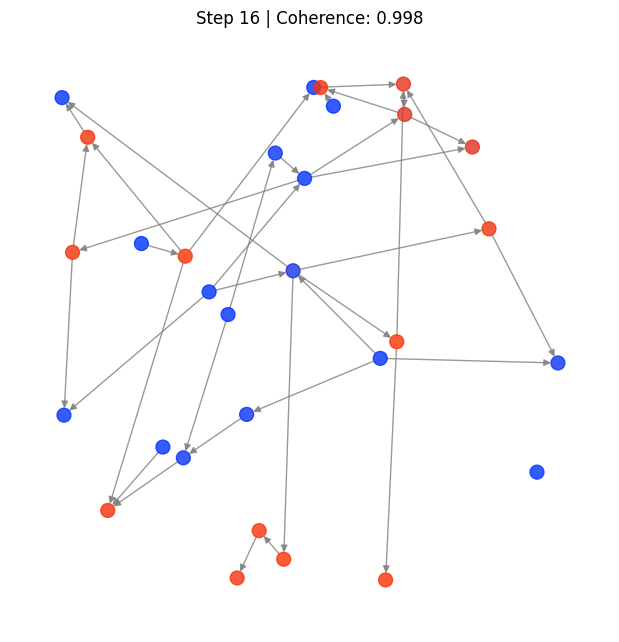

[STEP 17] coherence=0.9978 edges=35 pruned=2


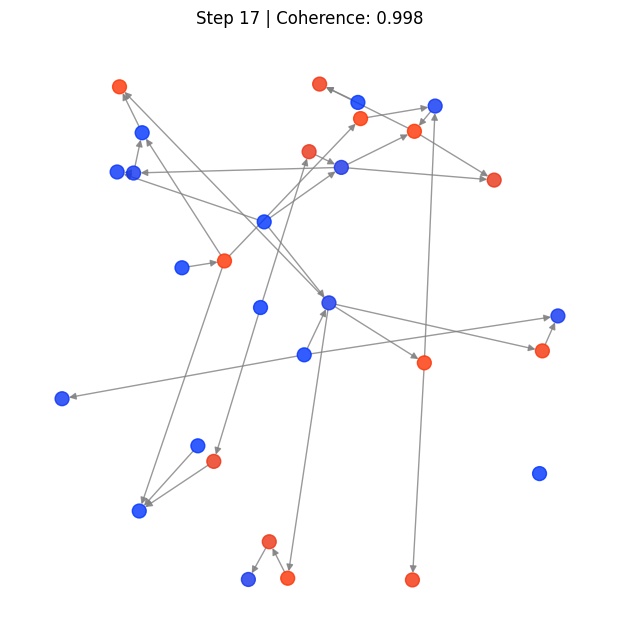

[STEP 18] coherence=0.9979 edges=33 pruned=2


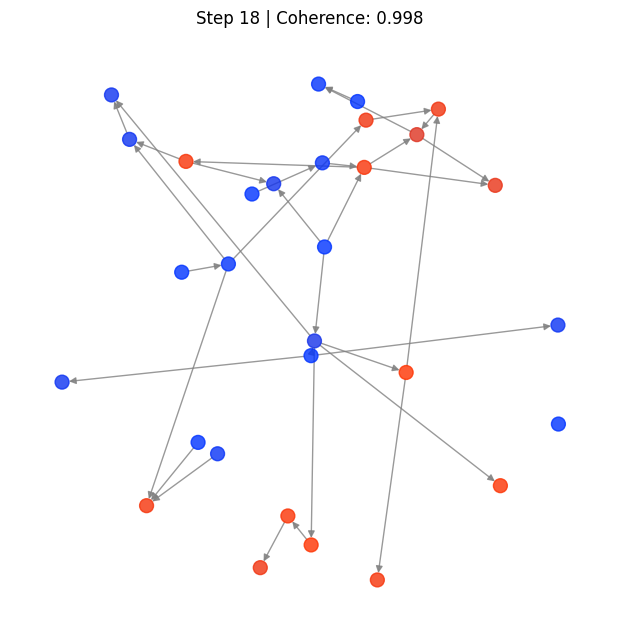

[STEP 19] coherence=0.9978 edges=29 pruned=4


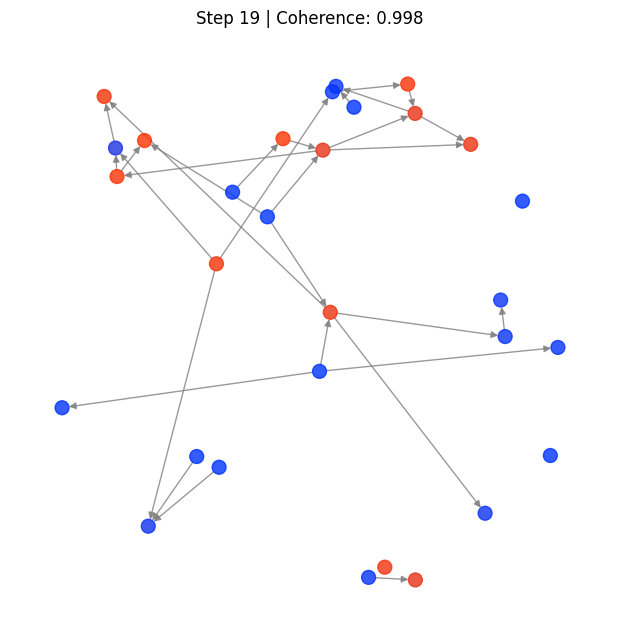

[STEP 20] coherence=0.9981 edges=26 pruned=3


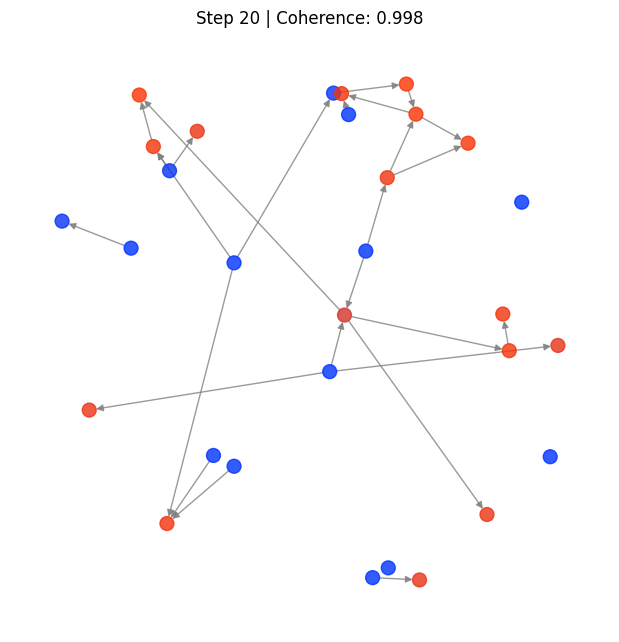

[STEP 21] coherence=0.9972 edges=23 pruned=3


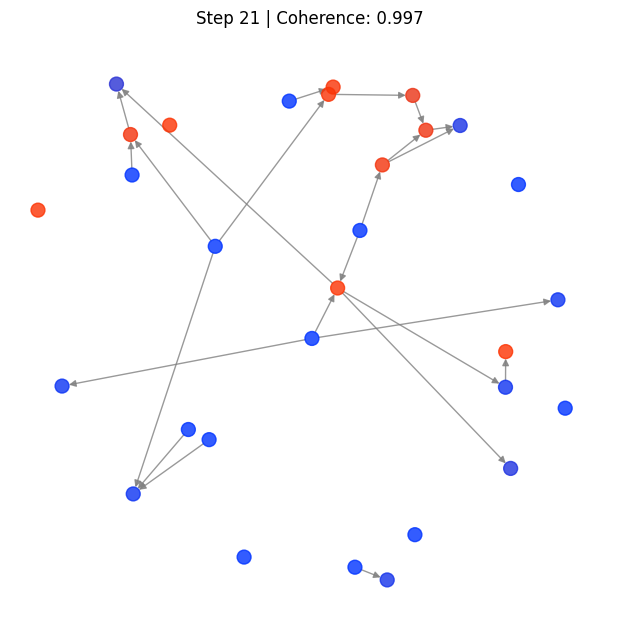

[STEP 22] coherence=0.9972 edges=22 pruned=1


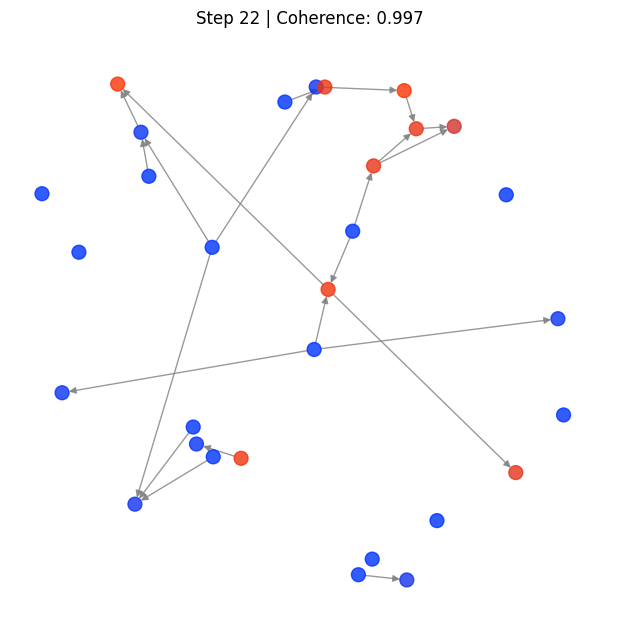

[STEP 23] coherence=0.9967 edges=19 pruned=3


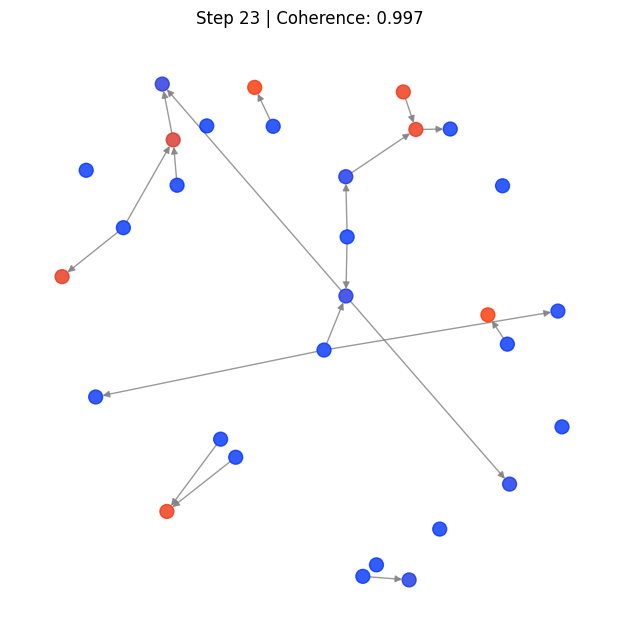

[STEP 24] coherence=0.9969 edges=19 pruned=0


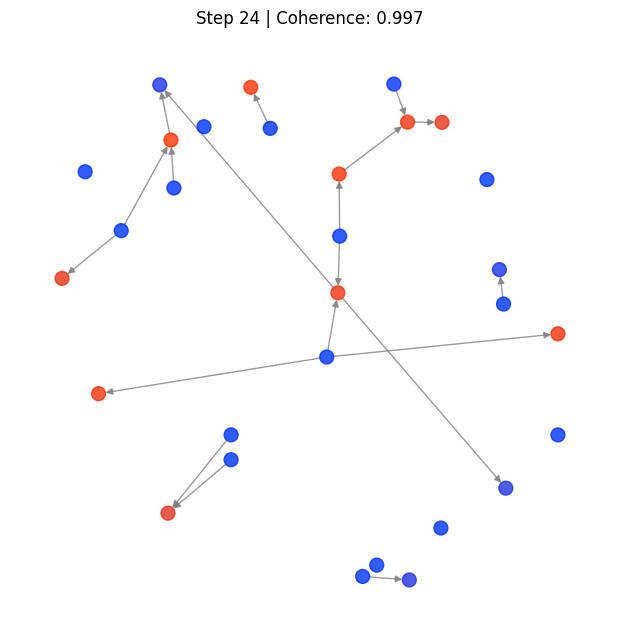

=== END ===


In [6]:
print("=== V-KERNEL FIELD SIMULATION ===")

for step in range(ITERATIONS):

    add_noise(G)

    new_vals = forward_pass(G)
    normalize(G, new_vals)

    reinforce(G)
    decay(G)

    removed = prune(G)

    coh = coherence(G)

    print(f"[STEP {step}] coherence={coh:.4f} edges={G.number_of_edges()} pruned={removed}")

    draw_graph(G, step, coh)

print("=== END ===")

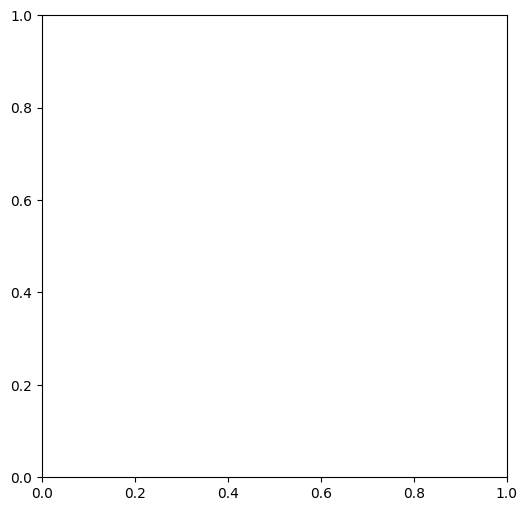

In [7]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(6,6))

pos = nx.spring_layout(G, seed=42)

def update(frame):
    ax.clear()

    add_noise(G)
    new_vals = forward_pass(G)
    normalize(G, new_vals)

    reinforce(G)
    decay(G)
    prune(G)

    coh = coherence(G)

    values = [G.nodes[n]["value"] for n in G.nodes]

    colors = []
    for v in values:
        if v > 0:
            colors.append((1-v, 0.2, v))
        else:
            colors.append((abs(v), 0.2, 1-abs(v)))

    nx.draw(G, pos, node_color=colors, node_size=100, ax=ax)

    ax.set_title(f"Step {frame} | Coherence {coh:.3f}")

ani = animation.FuncAnimation(fig, update, frames=30, interval=300)
plt.show()